In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind

In [10]:
# Read the files
actin_batch1 = pd.read_csv("Batch1_Actin_Actin.csv")
actin_batch1["Plate"] = "1"
actin_batch2 = pd.read_csv("Batch2_Actin_Actin.csv")
actin_batch2["Plate"] = "2"

# Get the metadata from the Image files
Image_batch1 = pd.read_csv("Batch1_Actin_Image.csv")
Image_batch2 = pd.read_csv("Batch2_Actin_Image.csv")

actin_batch1 = pd.merge(actin_batch1, Image_batch1, on = "ImageNumber")
actin_batch2 = pd.merge(actin_batch2, Image_batch2, on = "ImageNumber")

actin = pd.concat([actin_batch1, actin_batch2]) # Merge them without considering any batch effect since we're only looking at the number
# and average length that should not be effected by any batch effect

actin = actin[["Metadata_Well", "Metadata_Site", "Plate",
               "AreaShape_MajorAxisLength", "AreaShape_MinorAxisLength"]] # Drop most of the columns

In [11]:
# Get the mean number of actin segments and the mean length of actin segments on a FOV level
actin_grp = actin.groupby(["Plate", "Metadata_Well", "Metadata_Site"])
actin_number = actin_grp.size().reset_index()
actin_length = actin_grp["AreaShape_MajorAxisLength"].mean().reset_index()
actin_width = actin_grp["AreaShape_MinorAxisLength"].mean().reset_index()

actin_fov_mean = pd.merge(actin_number, actin_length, on=["Plate", "Metadata_Well", "Metadata_Site"])
actin_fov_mean = pd.merge(actin_fov_mean, actin_width, on=["Plate", "Metadata_Well", "Metadata_Site"])

actin_fov_mean.columns = ["Plate", "Metadata_Well", "Metadata_Site", "Actin_number", "Actin_Length", "Actin_Width"]

unique_values = actin_fov_mean["Metadata_Well"].unique()  # Assign the metadata

cell_line_info = {
    "B02": "JHOS2",
    "B03": "JHOS2",
    "B04": "JHOS2",
    "B05": "Kuramochi",
    "B06": "Kuramochi",
    "B07": "Ovsaho",
    "B08": "Ovsaho",
    "E01": "JHOS2",
    "E02": "JHOS2",
    "E03": "JHOS2",
    "E04": "JHOS2",
    "E05": "Kuramochi",
    "E06": "Kuramochi",
    "E07": "Ovsaho",
    "E08": "COV318",
    "E09": "COV318",
    "E10": "COV362"
}

treatment_info = {
    "B02": "parental",
    "B03": "AZD1775",
    "B04": "PTX",
    "B05": "parental",
    "B06": "AZD1775",
    "B07": "parental",
    "B08": "AZD1775",
    "E01": "PTX",
    "E02": "PTX",
    "E03": "AZD1775",
    "E04": "AZD1775",
    "E05": "parental",
    "E06": "AZD1775",
    "E07": "AZD1775",
    "E08": "parental",
    "E09": "PTX",
    "E10": "parental"
}

concentration_info = { 
    "B02": "none",
    "B03": "1 µM",
    "B04": "50 nM",
    "B05": "none",
    "B06": "2 µM",
    "B07": "none",
    "B08": "1.5 µM",
    "E01": "50 nM",
    "E02": "150 nM",
    "E03": "1 µM",
    "E04": "2 µM",
    "E05": "none",
    "E06": "2 µM",
    "E07": "1.5 µM",
    "E08": "none",
    "E09": "750 nM",
    "E10": "none"
}

cell_line_mapping = {}
treatment_mapping = {}
concentration_mapping = {}

for value in unique_values:
    cell_line_mapping[value] = cell_line_info.get(value, None)
    treatment_mapping[value] = treatment_info.get(value, None)
    concentration_mapping[value] = concentration_info.get(value, None)
    
actin_fov_mean["CellLine"] = actin_fov_mean["Metadata_Well"].map(lambda x: cell_line_mapping.get(x, None))
actin_fov_mean["Treatment"] = actin_fov_mean["Metadata_Well"].map(lambda x: treatment_mapping.get(x, None))
actin_fov_mean["Concentration"] = actin_fov_mean["Metadata_Well"].map(lambda x: concentration_mapping.get(x, None))
actin_fov_mean["Condition"] = actin_fov_mean.apply(lambda row: f"{row['CellLine']} parental" if row['Treatment'] == "parental" else f"{row['CellLine']} {row['Treatment']}res", axis=1)

In [12]:
# Create a new dataframe that contains COV318 and COV362 from the first plate and JHOS2, Kuramochi and Ovsaho from the second plate
# to make sure that we have control-treatment condition pairs always from the same plate

# Define the conditions to include
plate_1_cell_lines = ["COV318"]
plate_2_cell_lines = ["JHOS2", "Kuramochi", "Ovsaho"]

# Create a mask to filter the DataFrame
mask_batch_1 = (actin_fov_mean["CellLine"].isin(plate_1_cell_lines)) & (actin_fov_mean["Plate"] == "1")
mask_batch_2 = (actin_fov_mean["CellLine"].isin(plate_2_cell_lines)) & (actin_fov_mean["Plate"] == "2")
sel_cell_lines_all = actin_fov_mean[mask_batch_1 | mask_batch_2] # Filter the DataFrame

# AZD
azd_mask = sel_cell_lines_all["Treatment"].isin(["parental", "AZD1775"]) # Filter by parental and AZD1775
sel_cell_lines_AZD = sel_cell_lines_all[azd_mask]

# PTX
ptx_mask = sel_cell_lines_all["Treatment"].isin(["parental", "PTX"])
sel_cell_lines_PTX = sel_cell_lines_all[ptx_mask]

In [13]:
# Preparations for the plotting
# Function to find a new y position from the list
def get_y_position(max_value):
    # Find the y_value that is just above the max_value
    y_pos = next(y for y in y_values if y > max_value)
    y_values.remove(y_pos) # Remove the used y-value from the list
    return y_pos

JHOS2 parental vs JHOS2 AZD1775res): p-value = 0.5317546244767377
Kuramochi parental vs Kuramochi AZD1775res): p-value = 2.526416062485459e-06
Ovsaho parental vs Ovsaho AZD1775res): p-value = 0.11160741100079849


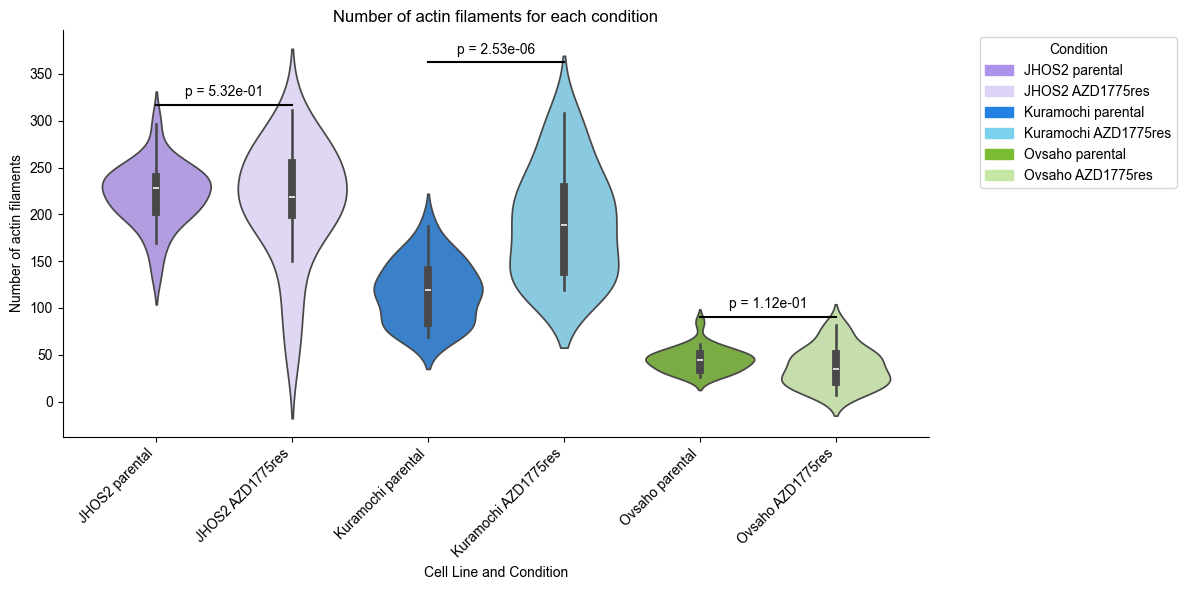

In [21]:
# Only AZD
sel_cell_lines = sel_cell_lines_AZD.copy()
# Define color mappings for conditions
cell_line_colors = {
    "JHOS2 AZD1775res": "#ddd3f7",
    "Kuramochi parental": "#2281E2",
    "Kuramochi AZD1775res": "#7CD1EE",
    "Ovsaho AZD1775res": "#c6e6a4",
    "JHOS2 parental": "#ac92eb",
    "Ovsaho parental": "#7abc34"
}

custom_order = ["JHOS2 parental", "JHOS2 AZD1775res",
                "Kuramochi parental", "Kuramochi AZD1775res",
                "Ovsaho parental", "Ovsaho AZD1775res"
]
sorted_colors = {cond: cell_line_colors[cond] for cond in custom_order}

# Filter the custom order to only include conditions present in the data
custom_order = [cond for cond in custom_order if cond in sel_cell_lines["Condition"].unique()]
sel_cell_lines["Condition"] = pd.Categorical(sel_cell_lines["Condition"], categories=custom_order, ordered=True) # Update sel_cell_lines["Condition"] to ensure the same order as the sorted legend

# Violinplot for the number of actin segments in each condition
plt.figure(figsize=(12, 6))
sns.violinplot(x="Condition", y="Actin_number", hue="Condition", data=sel_cell_lines, palette=sorted_colors)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Cell Line and Condition")
plt.ylabel("Number of actin filaments")
plt.title("Number of actin filaments for each condition")

# Create the custom legend with sorted titles
handles = [plt.Rectangle((0, 0), 1, 1, color=sorted_colors[key]) for key in custom_order]
plt.legend(handles, custom_order, title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
sns.despine()  # Remove the top and right spines (borders)

# Initialize a list of y-values in steps of 2.5 up to the maximum observed value in the dataframe
max_y = sel_cell_lines["Actin_number"].max()
y_values = np.arange(0, max_y + 20, 0.1 * max_y).tolist()

processed_comparisons = set()  # Initialize a set to keep track of processed comparisons

# Perform paired t-tests with the control samples and annotate
for cell_line in sel_cell_lines["CellLine"].unique():
    control_condition = cell_line + " " + "parental"
    control_data = sel_cell_lines[sel_cell_lines["Condition"] == control_condition]["Actin_number"]

    if len(control_data) <= 1:
        continue

    for condition in sel_cell_lines[sel_cell_lines["CellLine"] == cell_line]["Condition"].unique():
        if condition == control_condition:
            continue
        treatment_data = sel_cell_lines[sel_cell_lines["Condition"] == condition]["Actin_number"]

        if len(treatment_data) > 1:
            comparison_key = (control_condition, condition)
            if comparison_key in processed_comparisons:
                continue
            processed_comparisons.add(comparison_key)

            t_stat, p_value = ttest_ind(control_data.values, treatment_data.values, equal_var=False)
            print(f"{control_condition} vs {condition}): p-value = {p_value}")

            # Get positions for control and treatment conditions
            control_pos = custom_order.index(control_condition)
            treatment_pos = custom_order.index(condition)

            # Get a unique y position
            y_max = max(control_data.max(), treatment_data.max())
            new_y_pos = get_y_position(y_max)

            # Draw line
            plt.plot([control_pos, treatment_pos], [new_y_pos, new_y_pos], color="black")

            # Annotate p-value with an additional offset for text
            text_offset = 0.02 * max_y  # Adjust this value as needed for higher placement
            mid_pos = (control_pos + treatment_pos) / 2
            plt.text(mid_pos, new_y_pos + text_offset, f"p = {p_value:.2e}", ha="center")

# Save the figure
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
plt.savefig("Violinplots_Number of actin filaments_sel_cell_lines_Adjacent_FOV mean_AZD.pdf", dpi=300, bbox_inches="tight")
plt.show()

COV318 parental vs COV318 PTXres): p-value = 2.4198968519605925e-22
JHOS2 parental vs JHOS2 PTXres): p-value = 2.096616055007644e-08


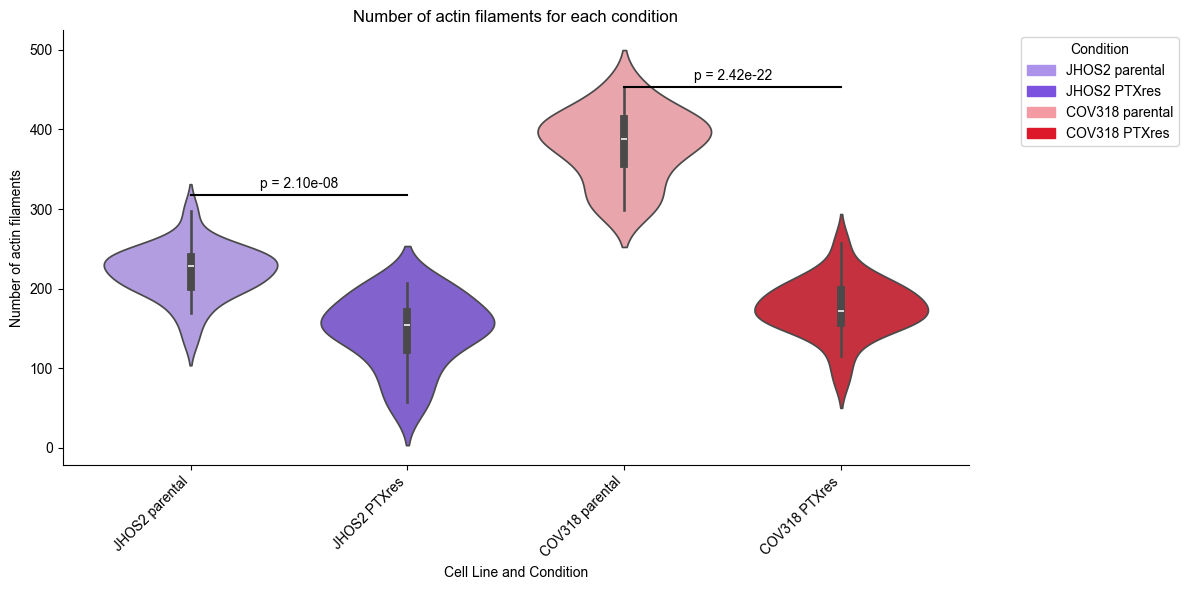

In [22]:
# Only PTX
sel_cell_lines = sel_cell_lines_PTX.copy()
# Define color mappings for conditions
cell_line_colors = {
    "JHOS2 PTXres": "#7b51df",
    "COV318 parental": "#f49aa3",
    "COV318 PTXres": "#de182b",
    "JHOS2 parental": "#ac92eb"
}

custom_order = ["JHOS2 parental", "JHOS2 PTXres",
                "COV318 parental", "COV318 PTXres"
]
sorted_colors = {cond: cell_line_colors[cond] for cond in custom_order}

# Filter the custom order to only include conditions present in the data
custom_order = [cond for cond in custom_order if cond in sel_cell_lines["Condition"].unique()]
sel_cell_lines["Condition"] = pd.Categorical(sel_cell_lines["Condition"], categories=custom_order, ordered=True) # Update sel_cell_lines["Condition"] to ensure the same order as the sorted legend

# Violinplot for the number of actin segments in each condition
plt.figure(figsize=(12, 6))
sns.violinplot(x="Condition", y="Actin_number", hue="Condition", data=sel_cell_lines, palette=sorted_colors)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Cell Line and Condition")
plt.ylabel("Number of actin filaments")
plt.title("Number of actin filaments for each condition")

# Create the custom legend with sorted titles
handles = [plt.Rectangle((0, 0), 1, 1, color=sorted_colors[key]) for key in custom_order]
plt.legend(handles, custom_order, title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
sns.despine()  # Remove the top and right spines (borders)

# Initialize a list of y-values in steps of 2.5 up to the maximum observed value in the dataframe
max_y = sel_cell_lines["Actin_number"].max()
y_values = np.arange(0, max_y + 20, 0.1 * max_y).tolist()

processed_comparisons = set()  # Initialize a set to keep track of processed comparisons

# Perform paired t-tests with the control samples and annotate
for cell_line in sel_cell_lines["CellLine"].unique():
    control_condition = cell_line + " " + "parental"
    control_data = sel_cell_lines[sel_cell_lines["Condition"] == control_condition]["Actin_number"]

    if len(control_data) <= 1:
        continue

    for condition in sel_cell_lines[sel_cell_lines["CellLine"] == cell_line]["Condition"].unique():
        if condition == control_condition:
            continue
        treatment_data = sel_cell_lines[sel_cell_lines["Condition"] == condition]["Actin_number"]

        if len(treatment_data) > 1:
            comparison_key = (control_condition, condition)
            if comparison_key in processed_comparisons:
                continue
            processed_comparisons.add(comparison_key)

            t_stat, p_value = ttest_ind(control_data.values, treatment_data.values, equal_var=False)
            print(f"{control_condition} vs {condition}): p-value = {p_value}")

            # Get positions for control and treatment conditions
            control_pos = custom_order.index(control_condition)
            treatment_pos = custom_order.index(condition)

            # Get a unique y position
            y_max = max(control_data.max(), treatment_data.max())
            new_y_pos = get_y_position(y_max)

            # Draw line
            plt.plot([control_pos, treatment_pos], [new_y_pos, new_y_pos], color="black")

            # Annotate p-value with an additional offset for text
            text_offset = 0.02 * max_y  # Adjust this value as needed for higher placement
            mid_pos = (control_pos + treatment_pos) / 2
            plt.text(mid_pos, new_y_pos + text_offset, f"p = {p_value:.2e}", ha="center")

# Save the figure
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
plt.savefig("Violinplots_Number of actin filaments_sel_cell_lines_Adjacent_FOV mean_PTX.pdf", dpi=300, bbox_inches="tight")
plt.show()

JHOS2 parental vs JHOS2 AZD1775res): p-value = 0.014739068990312035
Kuramochi parental vs Kuramochi AZD1775res): p-value = 0.018509742131702867
Ovsaho parental vs Ovsaho AZD1775res): p-value = 0.0003307912545097521


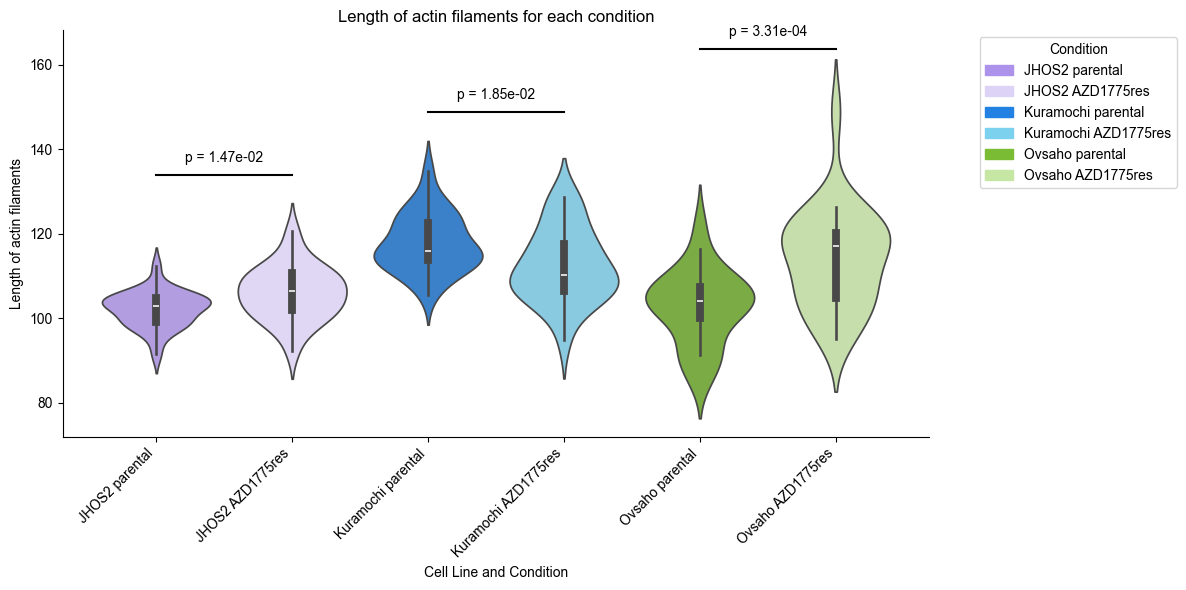

In [25]:
# Only AZD
sel_cell_lines = sel_cell_lines_AZD.copy()
# Define color mappings for conditions
cell_line_colors = {
    "JHOS2 AZD1775res": "#ddd3f7",
    "Kuramochi parental": "#2281E2",
    "Kuramochi AZD1775res": "#7CD1EE",
    "Ovsaho AZD1775res": "#c6e6a4",
    "JHOS2 parental": "#ac92eb",
    "Ovsaho parental": "#7abc34"
}

custom_order = ["JHOS2 parental", "JHOS2 AZD1775res",
                "Kuramochi parental", "Kuramochi AZD1775res",
                "Ovsaho parental", "Ovsaho AZD1775res"
]
sorted_colors = {cond: cell_line_colors[cond] for cond in custom_order}

# Filter the custom order to only include conditions present in the data
custom_order = [cond for cond in custom_order if cond in sel_cell_lines["Condition"].unique()]

# Update sel_cell_lines["Condition"] to ensure the same order as the sorted legend
sel_cell_lines["Condition"] = pd.Categorical(sel_cell_lines["Condition"], categories=custom_order, ordered=True)

# Violinplot for the number of actin segments in each condition
plt.figure(figsize=(12, 6))
sns.violinplot(x="Condition", y="Actin_Length", hue="Condition", data=sel_cell_lines, palette=sorted_colors)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Cell Line and Condition")
plt.ylabel("Length of actin filaments")
plt.title("Length of actin filaments for each condition")

# Create the custom legend with sorted titles
handles = [plt.Rectangle((0, 0), 1, 1, color=sorted_colors[key]) for key in custom_order]
plt.legend(handles, custom_order, title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
sns.despine()  # Remove the top and right spines (borders)

# Initialize a list of y-values in steps of 2.5 up to the maximum observed value in the dataframe
max_y = sel_cell_lines["Actin_Length"].max()
y_values = np.arange(0, max_y + 20, 0.1 * max_y).tolist()

processed_comparisons = set()  # Initialize a set to keep track of processed comparisons

# Perform paired t-tests with the control samples and annotate
for cell_line in sel_cell_lines["CellLine"].unique():
    control_condition = cell_line + " " + "parental"
    control_data = sel_cell_lines[sel_cell_lines["Condition"] == control_condition]["Actin_Length"]

    if len(control_data) <= 1:
        continue

    for condition in sel_cell_lines[sel_cell_lines["CellLine"] == cell_line]["Condition"].unique():
        if condition == control_condition:
            continue
        treatment_data = sel_cell_lines[sel_cell_lines["Condition"] == condition]["Actin_Length"]

        if len(treatment_data) > 1:
            comparison_key = (control_condition, condition)
            if comparison_key in processed_comparisons:
                continue
            processed_comparisons.add(comparison_key)

            t_stat, p_value = ttest_ind(control_data.values, treatment_data.values, equal_var=False)
            print(f"{control_condition} vs {condition}): p-value = {p_value}")

            # Get positions for control and treatment conditions
            control_pos = custom_order.index(control_condition)
            treatment_pos = custom_order.index(condition)

            # Get a unique y position
            y_max = max(control_data.max(), treatment_data.max())
            new_y_pos = get_y_position(y_max)

            # Draw line
            plt.plot([control_pos, treatment_pos], [new_y_pos, new_y_pos], color="black")

            # Annotate p-value with an additional offset for text
            text_offset = 0.02 * max_y  # Adjust this value as needed for higher placement
            mid_pos = (control_pos + treatment_pos) / 2
            plt.text(mid_pos, new_y_pos + text_offset, f"p = {p_value:.2e}", ha="center")

# Save the figure
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
plt.savefig("Violinplots_Length of actin filaments_sel_cell_lines_Adjacent_FOV mean_AZD.pdf", dpi=300, bbox_inches="tight")
plt.show()

{'JHOS2 parental': '#ac92eb', 'JHOS2 PTXres': '#7b51df', 'COV318 parental': '#f49aa3', 'COV318 PTXres': '#de182b'}
COV318 parental vs COV318 PTXres): p-value = 2.108266187952099e-06
JHOS2 parental vs JHOS2 PTXres): p-value = 0.0007874056494130467


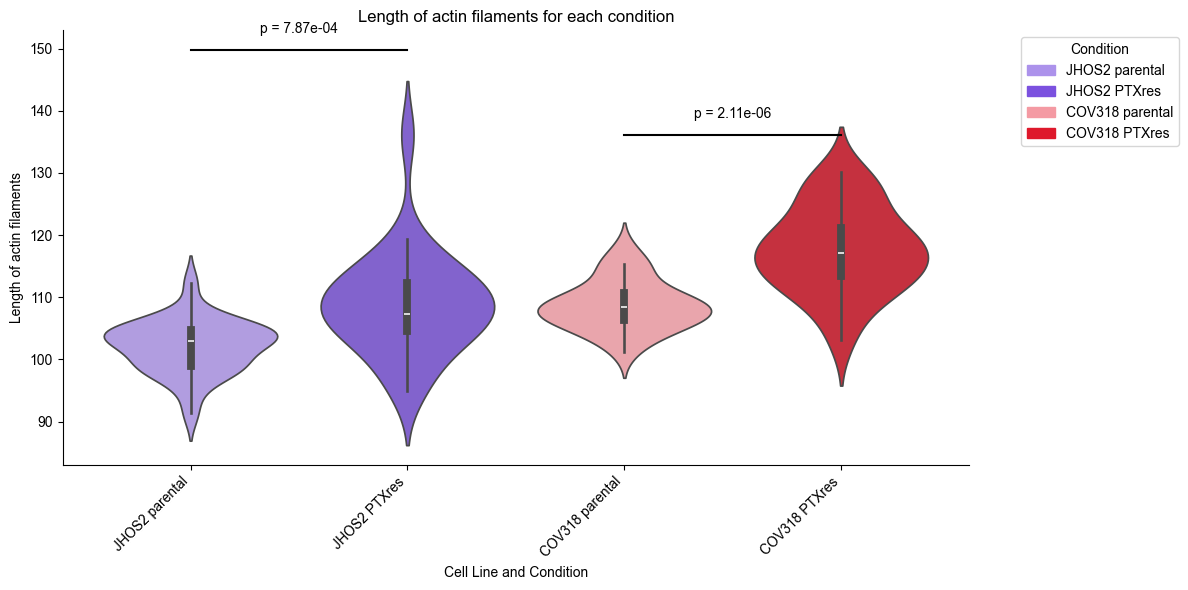

In [18]:
# Only PTX
sel_cell_lines = sel_cell_lines_PTX.copy()
# Define color mappings for conditions
cell_line_colors = {
    "JHOS2 PTXres": "#7b51df",
    "COV318 parental": "#f49aa3",
    "COV318 PTXres": "#de182b",
    "JHOS2 parental": "#ac92eb"
}

custom_order = ["JHOS2 parental", "JHOS2 PTXres",
                "COV318 parental", "COV318 PTXres"
]
sorted_colors = {cond: cell_line_colors[cond] for cond in custom_order}

# Filter the custom order to only include conditions present in the data
custom_order = [cond for cond in custom_order if cond in sel_cell_lines["Condition"].unique()]

# Update sel_cell_lines["Condition"] to ensure the same order as the sorted legend
sel_cell_lines["Condition"] = pd.Categorical(sel_cell_lines["Condition"], categories=custom_order, ordered=True)

# Violinplot for the number of actin segments in each condition
plt.figure(figsize=(12, 6))
sns.violinplot(x="Condition", y="Actin_Length", hue="Condition", data=sel_cell_lines, palette=sorted_colors)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Cell Line and Condition")
plt.ylabel("Length of actin filaments")
plt.title("Length of actin filaments for each condition")

# Create the custom legend with sorted titles
handles = [plt.Rectangle((0, 0), 1, 1, color=sorted_colors[key]) for key in custom_order]
plt.legend(handles, custom_order, title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
sns.despine()  # Remove the top and right spines (borders)

# Initialize a list of y-values in steps of 2.5 up to the maximum observed value in the dataframe
max_y = sel_cell_lines["Actin_Length"].max()
y_values = np.arange(0, max_y + 20, 0.1 * max_y).tolist()

processed_comparisons = set()  # Initialize a set to keep track of processed comparisons

# Perform paired t-tests with the control samples and annotate
for cell_line in sel_cell_lines["CellLine"].unique():
    control_condition = cell_line + " " + "parental"
    control_data = sel_cell_lines[sel_cell_lines["Condition"] == control_condition]["Actin_Length"]

    if len(control_data) <= 1:
        continue

    for condition in sel_cell_lines[sel_cell_lines["CellLine"] == cell_line]["Condition"].unique():
        if condition == control_condition:
            continue
        treatment_data = sel_cell_lines[sel_cell_lines["Condition"] == condition]["Actin_Length"]

        if len(treatment_data) > 1:
            comparison_key = (control_condition, condition)
            if comparison_key in processed_comparisons:
                continue
            processed_comparisons.add(comparison_key)

            t_stat, p_value = ttest_ind(control_data.values, treatment_data.values, equal_var=False)
            print(f"{control_condition} vs {condition}): p-value = {p_value}")

            # Get positions for control and treatment conditions
            control_pos = custom_order.index(control_condition)
            treatment_pos = custom_order.index(condition)

            # Get a unique y position
            y_max = max(control_data.max(), treatment_data.max())
            new_y_pos = get_y_position(y_max)

            # Draw line
            plt.plot([control_pos, treatment_pos], [new_y_pos, new_y_pos], color="black")

            # Annotate p-value with an additional offset for text
            text_offset = 0.02 * max_y  # Adjust this value as needed for higher placement
            mid_pos = (control_pos + treatment_pos) / 2
            plt.text(mid_pos, new_y_pos + text_offset, f"p = {p_value:.2e}", ha="center")

# Save the figure
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
plt.savefig("Violinplots_Length of actin filaments_sel_cell_lines_Adjacent_FOV mean_PTX.pdf", dpi=300, bbox_inches="tight")
plt.show()